

## Bước 1: Phân tích yêu cầu (Refine Requirement)

**Mục tiêu:** Nắm vững các thao tác tiền xử lý ảnh cơ bản bằng Python, sử dụng thư viện OpenCV và Pillow.

**Đầu vào:** Các file ảnh tĩnh thuộc nhiều định dạng khác nhau (.jpg, .png,...).

**Đầu ra:** Các file ảnh đã qua xử lý (chuyển đổi không gian màu, biến đổi hình học, vẽ hình, chèn văn bản, nén lưu trữ) và hiển thị kết quả trực quan trên giao diện.

## Bước 2: Hiểu về dữ liệu (Data Understanding)

**Cấu trúc ma trận ảnh số:**
*   **Ảnh xám (Grayscale):** Lưu trữ dưới dạng ma trận 2D $(H \times W)$, giá trị mỗi pixel là một số nguyên từ $0$ (đen) đến $255$ (trắng) kiểu `uint8`.
*   **Ảnh màu (Color):** Lưu trữ dưới dạng ma trận 3D $(H \times W \times C)$, với $C = 3$ kênh màu.

**Đặc tính kênh màu trong OpenCV:**
*   Mặc định OpenCV đọc ảnh theo thứ tự kênh màu BGR (Blue - Green - Red).
*   Khi làm việc với Matplotlib hoặc Pillow (vốn dùng chuẩn RGB), cần thực hiện chuyển đổi kênh màu để tránh bị lệch màu sắc.

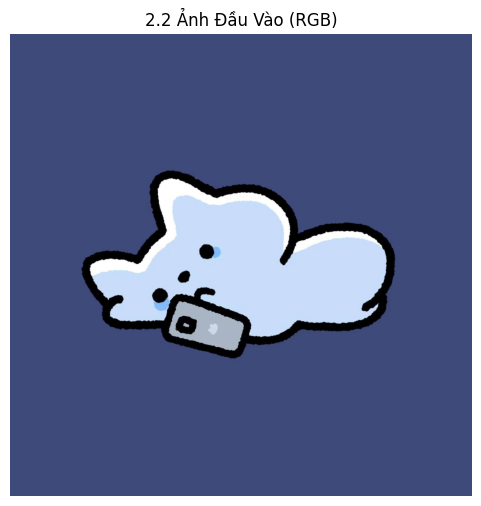

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ============================================================
# MỤC 1 & 2: ĐỌC, HIỂN THỊ VÀ LƯU ẢNH
# ============================================================
file_input = 'meme.jpg'
img_bgr = cv2.imread(file_input)

if img_bgr is None:
    print(f"LỖI: Không tìm thấy file '{file_input}'. Đang tạo canvas mẫu...")
    img_bgr = np.full((500, 500, 3), 200, dtype=np.uint8)

# 2.2 Hiển thị ảnh (Chuyển BGR -> RGB)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title("2.2 Ảnh Đầu Vào (RGB)")
plt.axis("off")
plt.show()

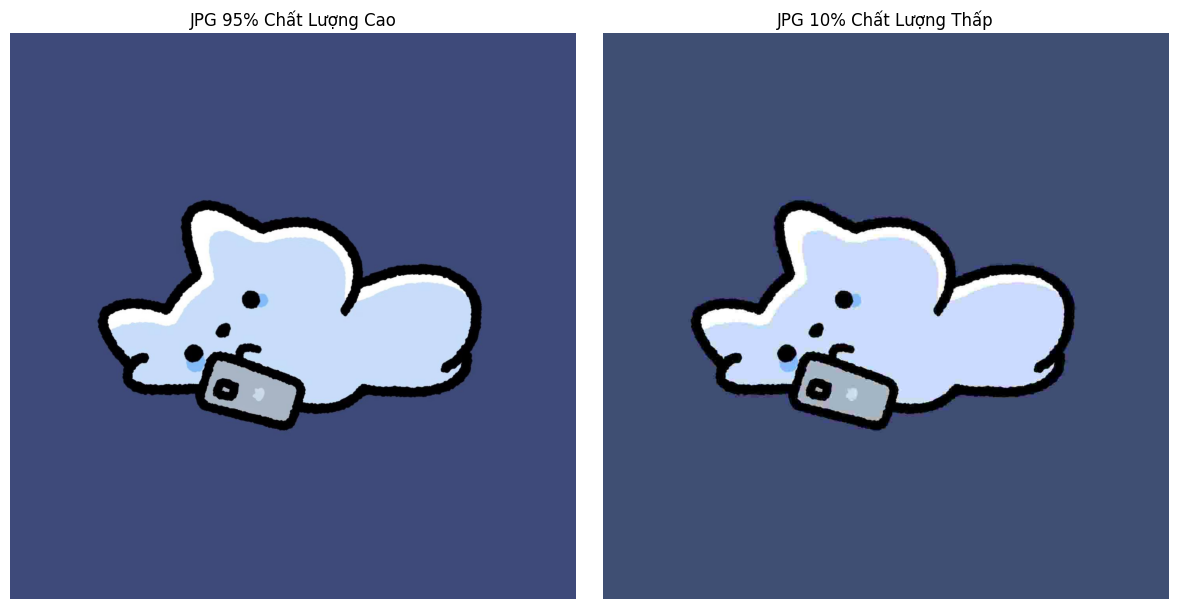

In [10]:
cv2.imwrite('output_goc.png', img_bgr)                                            # PNG Lossless
cv2.imwrite('output_high_quality.jpg', img_bgr, [cv2.IMWRITE_JPEG_QUALITY, 95])   # JPG 95%
cv2.imwrite('output_low_quality.jpg', img_bgr, [cv2.IMWRITE_JPEG_QUALITY, 10])    # JPG 10%
cv2.imwrite('output_compressed.webp', img_bgr, [cv2.IMWRITE_WEBP_QUALITY, 80])   # WebP 80%

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
img_high_quality = cv2.imread('output_high_quality.jpg')
img_high_quality_rgb = cv2.cvtColor(img_high_quality, cv2.COLOR_BGR2RGB)
plt.imshow(img_high_quality_rgb)
plt.title('JPG 95% Chất Lượng Cao')
plt.axis('off')

plt.subplot(1, 2, 2)
img_low_quality = cv2.imread('output_low_quality.jpg')
img_low_quality_rgb = cv2.cvtColor(img_low_quality, cv2.COLOR_BGR2RGB)
plt.imshow(img_low_quality_rgb)
plt.title('JPG 10% Chất Lượng Thấp')
plt.axis('off')

plt.tight_layout()
plt.show()

# MỤC 3: CHUYỂN ĐỔI KHÔNG GIAN MÀU

## Bước 3: Xác định Tính năng (Feature)

Các tính năng chính được xác định để thực hiện các thao tác tiền xử lý ảnh:

*   **F1 - Environment Setup:** Khởi tạo môi trường lập trình và tích hợp thư viện `opencv-python`, `Pillow`.
*   **F2 - Image I/O & Display:** Đọc ảnh từ đĩa, hiển thị ảnh lên màn hình giao diện và xuất ảnh ra đĩa dưới nhiều định dạng/mức độ nén khác nhau.
*   **F3 - Color Space Conversion:** Chuyển đổi giữa các không gian màu RGB/BGR, Grayscale, HSV và LAB.
*   **F4 - Geometric Transformation:** Cắt xén vùng ảnh chọn lọc (Crop) và thay đổi kích thước ảnh (Resize) theo tỷ lệ/kích thước cố định.
*   **F5 - Image Annotation:** Vẽ các đối tượng đồ họa cơ bản (đường thẳng, hình tròn, hình chữ nhật) và chèn văn bản lên ảnh.

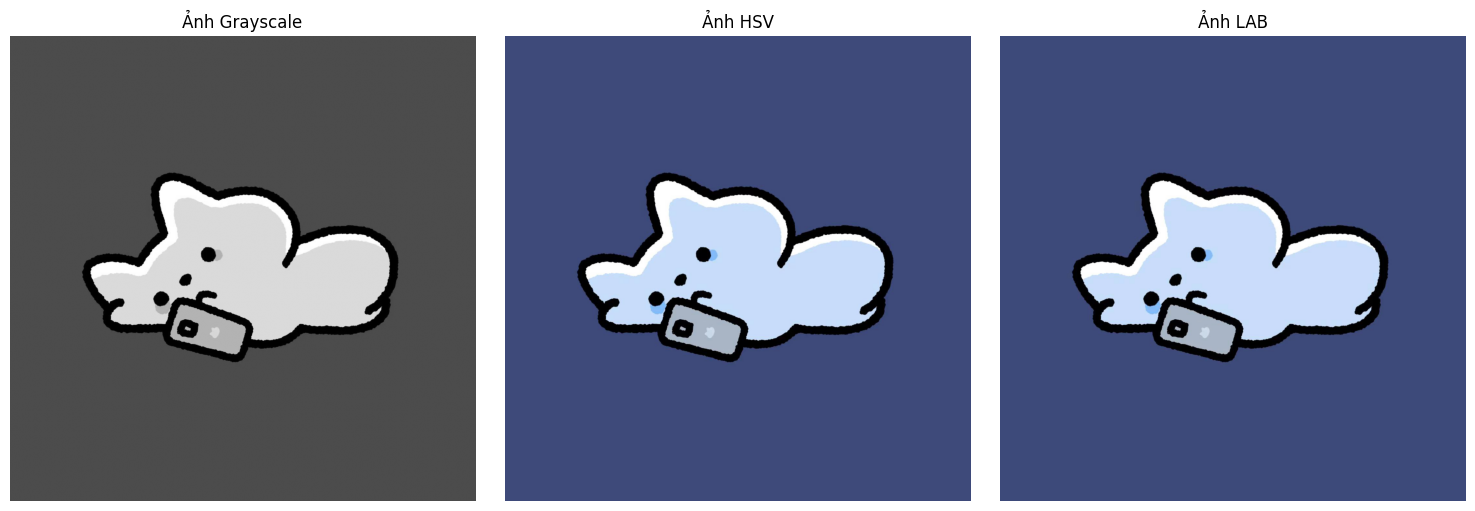

In [11]:
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)  # 3.1 RGB/BGR -> Grayscale
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)    # 3.2 BGR -> HSV
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)    # 3.2 BGR -> LAB

cv2.imwrite('output_gray.jpg', img_gray)
cv2.imwrite('output_hsv.jpg', img_hsv)
cv2.imwrite('output_lab.jpg', img_lab)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Ảnh Grayscale')
plt.axis('off')

plt.subplot(1, 3, 2)
# HSV và LAB cần được chuyển về RGB để Matplotlib hiển thị đúng màu
img_hsv_rgb = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB)
plt.imshow(img_hsv_rgb)
plt.title('Ảnh HSV')
plt.axis('off')

plt.subplot(1, 3, 3)
img_lab_rgb = cv2.cvtColor(img_lab, cv2.COLOR_LAB2RGB)
plt.imshow(img_lab_rgb)
plt.title('Ảnh LAB')
plt.axis('off')

plt.tight_layout()
plt.show()

# MỤC 4: CẮT XÉN (CROP) VÀ THAY ĐỔI KÍCH THƯỚC (RESIZE)

## Bước 4: Giải pháp Kỹ thuật (Technical Solution)

1.  **Cài đặt thư viện:** Sử dụng trình quản lý gói `pip` để cài đặt `opencv-python` và `Pillow`.
2.  **Đọc, Hiển thị và Lưu ảnh:**
    *   Đọc & Hiển thị: Dùng `cv2.imread()` để nạp ảnh. Chuyển BGR sang RGB bằng `cv2.cvtColor()` trước khi hiển thị qua `plt.imshow()`.
    *   Lưu ảnh & Nén: Dùng `cv2.imwrite()` kết hợp các tham số điều khiển chất lượng nén (ví dụ: `cv2.IMWRITE_JPEG_QUALITY`, `cv2.IMWRITE_WEBP_QUALITY`).
3.  **Chuyển đổi không gian màu:**
    *   Công thức biến đổi Grayscale: $I = 0.2989R + 0.5870G + 0.1140B$ (thông qua mã màu `cv2.COLOR_BGR2GRAY`).
    *   Chuyển đổi HSV/LAB: Sử dụng `cv2.COLOR_BGR2HSV` và `cv2.COLOR_BGR2LAB`.
4.  **Cắt xén và Thay đổi kích thước:**
    *   Crop: Thao tác trực tiếp trên mảng NumPy `image[y1:y2, x1:x2]`.
    *   Resize: Dùng `cv2.resize(src, dsize, fx, fy, interpolation)`.
5.  **Vẽ hình và Thêm văn bản:** Áp dụng các hàm vẽ đồ họa của OpenCV: `cv2.line()`, `cv2.circle()`, `cv2.rectangle()`, và `cv2.putText()`. Sử dụng cờ `cv2.LINE_AA` để khử răng cưa.

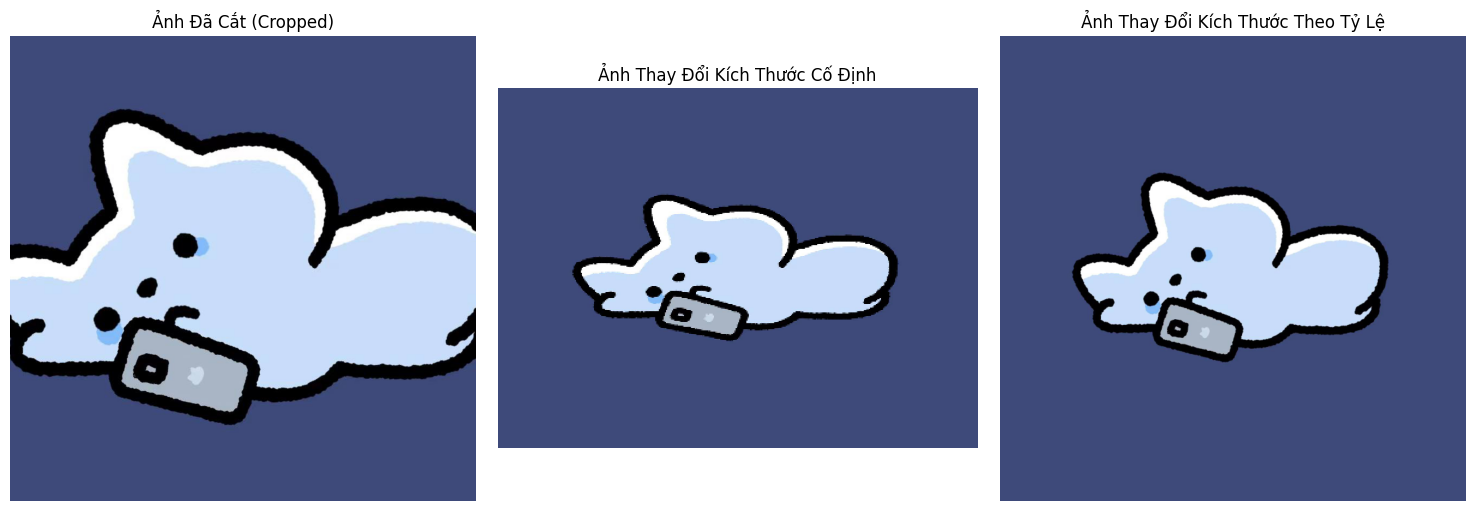

In [12]:
h, w, _ = img_bgr.shape
# 4.1 Crop vùng trung tâm ảnh
cropped_img = img_bgr[int(h*0.2):int(h*0.8), int(w*0.2):int(w*0.8)]
cv2.imwrite('output_cropped.jpg', cropped_img)

# 4.2 Resize kích thước cố định và theo tỷ lệ
resized_fixed = cv2.resize(img_bgr, (400, 300))
resized_scaled = cv2.resize(img_bgr, (0, 0), fx=0.5, fy=0.5)

cv2.imwrite('output_resized_fixed.jpg', resized_fixed)
cv2.imwrite('output_resized_scaled.jpg', resized_scaled)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
img_cropped_display = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB)
plt.imshow(img_cropped_display)
plt.title('Ảnh Đã Cắt (Cropped)')
plt.axis('off')

plt.subplot(1, 3, 2)
img_resized_fixed_rgb = cv2.cvtColor(resized_fixed, cv2.COLOR_BGR2RGB)
plt.imshow(img_resized_fixed_rgb)
plt.title('Ảnh Thay Đổi Kích Thước Cố Định')
plt.axis('off')

plt.subplot(1, 3, 3)
img_resized_scaled_rgb = cv2.cvtColor(resized_scaled, cv2.COLOR_BGR2RGB)
plt.imshow(img_resized_scaled_rgb)
plt.title('Ảnh Thay Đổi Kích Thước Theo Tỷ Lệ')
plt.axis('off')

plt.tight_layout()
plt.show()

# MỤC 5: VẼ HÌNH CƠ BẢN VÀ THÊM VĂN BẢN

## Bước 5: Hiện thực hóa (Implementation)

Mã nguồn Python đã được cung cấp để thực hiện các chức năng từ Mục 1 đến Mục 5. Code đã được tạo thành các cell Python riêng biệt trong notebook này, với `file_input` được cập nhật thành `'meme.jpg'` theo yêu cầu của bạn. Các bước bao gồm:

*   **Đọc, Hiển thị và Lưu ảnh:** Đọc `meme.jpg`, hiển thị ảnh RGB và lưu ảnh ra các định dạng PNG, JPG (chất lượng cao và thấp), WebP.
*   **Chuyển đổi không gian màu:** Chuyển đổi ảnh gốc sang Grayscale, HSV và LAB, sau đó lưu các ảnh đã chuyển đổi.
*   **Cắt xén và Thay đổi kích thước:** Cắt một phần trung tâm của ảnh, thay đổi kích thước ảnh theo kích thước cố định và theo tỷ lệ, sau đó lưu các ảnh này.
*   **Vẽ hình và Thêm văn bản:** Tạo một canvas trắng và vẽ các hình cơ bản (đường thẳng, hình tròn, hình chữ nhật) cùng với chèn văn bản "Computer Vision 2026" lên canvas, sau đó lưu canvas đã chú thích.

Đã hoàn tất xử lý và lưu toàn bộ kết quả Lab 1!


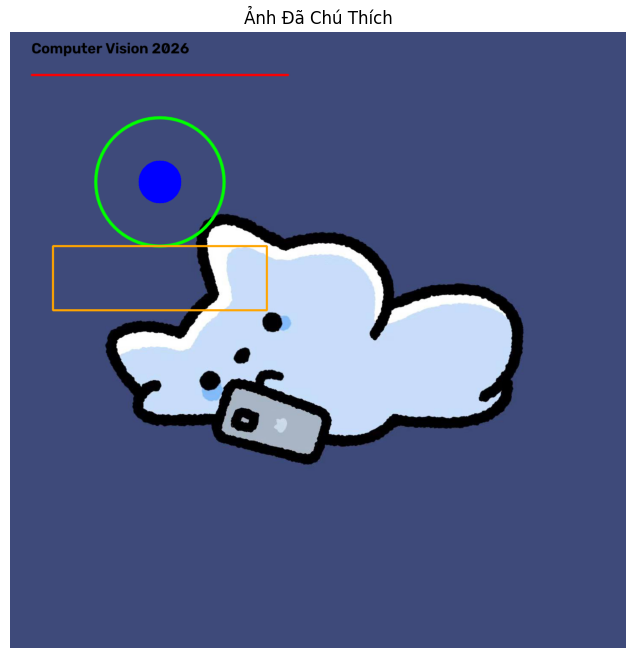

In [13]:
canvas = img_bgr.copy() # Sử dụng ảnh gốc meme.jpg làm nền để vẽ

# 5.1 Vẽ hình
cv2.line(canvas, (50, 100), (650, 100), (0, 0, 255), 3, cv2.LINE_AA)              # Đường thẳng
cv2.circle(canvas, (350, 350), 150, (0, 255, 0), 5, cv2.LINE_AA)                   # Hình tròn rỗng
cv2.circle(canvas, (350, 350), 50, (255, 0, 0), -1)                               # Hình tròn tô đặc
cv2.rectangle(canvas, (100, 500), (600, 650), (0, 165, 255), 4)                    # Hình chữ nhật

# 5.2 Thêm văn bản
cv2.putText(canvas, "Computer Vision 2026", (50, 50),
            cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 0), 2, cv2.LINE_AA)

cv2.imwrite('output_canvas_annotated.jpg', canvas)
print("Đã hoàn tất xử lý và lưu toàn bộ kết quả Lab 1!")

plt.figure(figsize=(8, 8))
img_annotated_display = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)
plt.imshow(img_annotated_display)
plt.title('Ảnh Đã Chú Thích')
plt.axis('off')
plt.show()

## Bước 6: Kiểm thử & Đánh giá (Testing & Evaluation)

**Tầng 1 - Đánh giá chức năng (Model/Function Level):**
*   **Chất lượng nén:** File JPG mức chất lượng 10% xuất hiện nhiễu khối (block artifacts) rõ rệt, dung lượng giảm mạnh so với file PNG hoặc JPG 95%.
*   **Biến đổi màu:** Ảnh chuyển sang không gian màu HSV tách biệt rõ ràng thông tin màu sắc (Hue) và độ sáng (Value), thuận tiện cho việc tách ngưỡng màu ở các bài lab sau.

**Tầng 2 - Đánh giá toàn bộ luồng (Full-flow Level):**
*   Chuỗi xử lý từ đọc ảnh -> biến đổi -> lưu trữ diễn ra mượt mà, không gặp lỗi tràn bộ nhớ hay lỗi định dạng dữ liệu NumPy.
*   Việc áp dụng cờ `cv2.LINE_AA` giúp các nét vẽ và văn bản chèn vào ảnh nét, mượt và không bị hiện tượng răng cưa.

## Hiển thị Kết quả Xử lý Ảnh

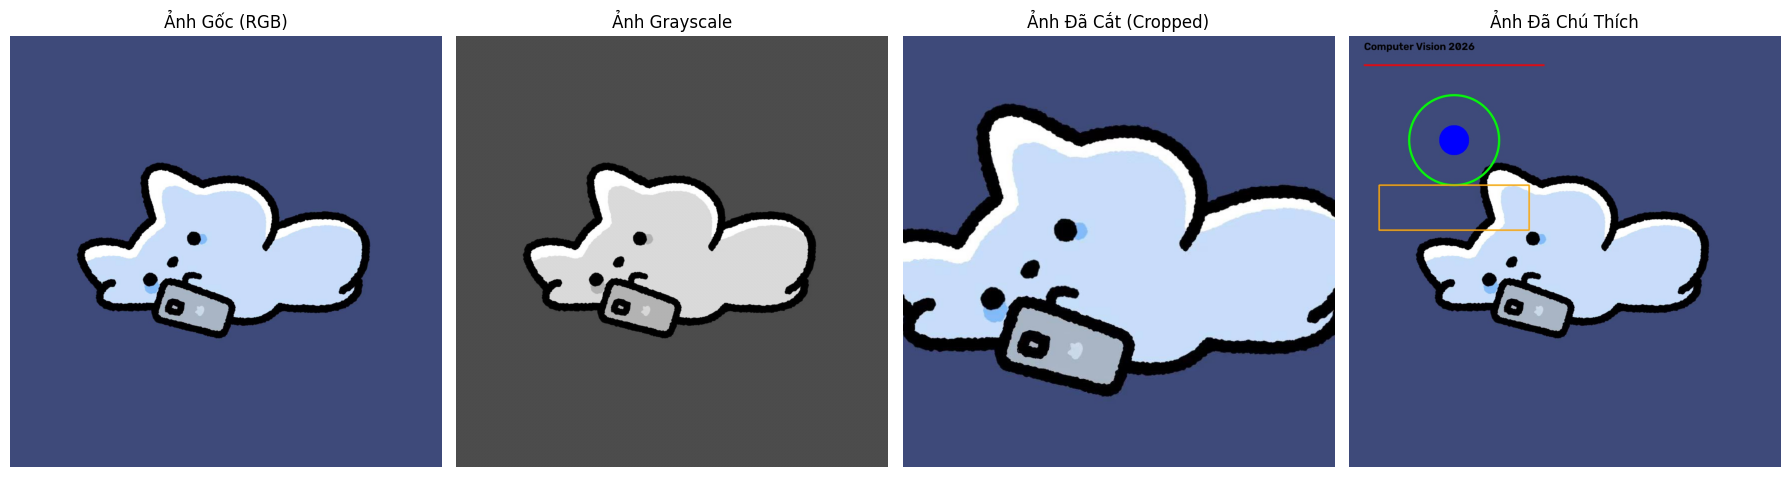

In [9]:
plt.figure(figsize=(18, 6))

# 1. Ảnh Gốc (RGB)
plt.subplot(1, 4, 1)
plt.imshow(img_rgb)
plt.title('Ảnh Gốc (RGB)')
plt.axis('off')

# 2. Ảnh Grayscale
img_gray_display = cv2.imread('output_gray.jpg', cv2.IMREAD_GRAYSCALE)
plt.subplot(1, 4, 2)
plt.imshow(img_gray_display, cmap='gray')
plt.title('Ảnh Grayscale')
plt.axis('off')

# 3. Ảnh Đã Cắt (Cropped)
img_cropped_display = cv2.imread('output_cropped.jpg')
img_cropped_display_rgb = cv2.cvtColor(img_cropped_display, cv2.COLOR_BGR2RGB)
plt.subplot(1, 4, 3)
plt.imshow(img_cropped_display_rgb)
plt.title('Ảnh Đã Cắt (Cropped)')
plt.axis('off')

# 4. Ảnh Đã Chú Thích (Cập Nhật)
img_canvas_annotated_display = cv2.imread('output_canvas_annotated.jpg')
img_canvas_annotated_display_rgb = cv2.cvtColor(img_canvas_annotated_display, cv2.COLOR_BGR2RGB)
plt.subplot(1, 4, 4)
plt.imshow(img_canvas_annotated_display_rgb)
plt.title('Ảnh Đã Chú Thích')
plt.axis('off')

plt.tight_layout()
plt.show()